# Exercise 4.A Introduction to Linear Regression

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [18]:
# Contents of linear_regression_example.py
# Sample dataset: hours studied vs exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 70, 75, 80, 85, 90, 95]
}
df = pd.DataFrame(data)

# Define feature matrix X and target vector y
X = df[['hours_studied']]
y = df['exam_score']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [19]:
# Print the slope and intercept of the fitted model
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept:           {model.intercept_:.2f}')


Slope (coefficient): 4.84
Intercept:           46.10


In [20]:
# Make predictions on the test set and compare to actual values
y_pred = model.predict(X_test)

print('Actual scores:   ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:    [90, 55]
Predicted scores: [89.7, 55.8]


In [21]:
# Evaluate the model using R² score
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.999


**What does the R² score mean?** R² (R-squared) measures how much of the variation in the target variable (exam score) is explained by the model's input variable (hours studied). A value of 1.0 means the model perfectly predicts every outcome; a value of 0 means the model explains none of the variation. An R² close to 1.0 here means that hours studied is a very strong predictor of exam score and the model fits the data well.

C:\Users\godkn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


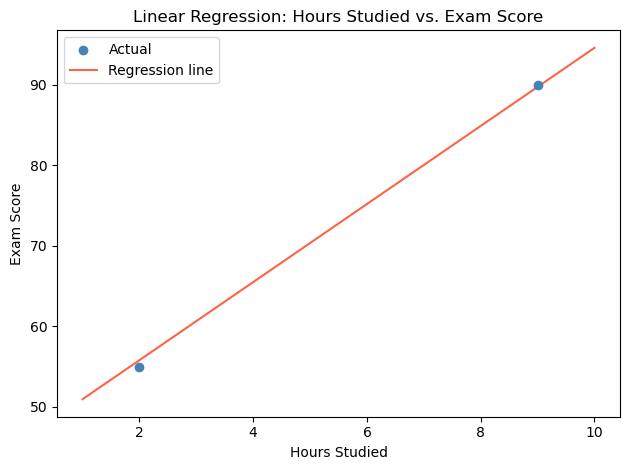

In [22]:
# Visualize the regression line overlaid on the test data scatter plot
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100).reshape(-1, 1)
y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

**Visual observation:** The actual data points follow the regression line very closely, with little scatter. This confirms what the R² score indicated, there is a strong, consistent linear relationship between hours studied and exam score in this dataset. The line passes through or very near each point, suggesting the model is a good fit.

## Lab 2
### Building your own model

In [23]:
# Create the ad spend / revenue DataFrame
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue':  [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
                         12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}
df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [24]:
# Define feature matrix X2 and target vector y2
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print('X2 shape:', X2.shape)
print('y2 shape:', y2.shape)

X2 shape: (20, 1)
y2 shape: (20,)


In [25]:
# Split into training and test sets
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [26]:
# Create, fit, and confirm model2
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
print('Model trained successfully.')

Model trained successfully.


In [27]:
# Print slope and intercept, with business interpretation
print(f'Slope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept:           {model2.intercept_:.2f}')

# For each additional $1 spent on ads, the predicted monthly revenue increases by ~$2.20.
# The intercept represents the estimated baseline revenue when ad spend is $0.

Slope (coefficient): 1.96
Intercept:           3625.89


### Making predictions and evaluating the model

In [28]:
# Predict revenue for the test set and print actual vs predicted side by side
y2_pred = model2.predict(X2_test)

print('Actual revenue:   ', list(y2_test))
print('Predicted revenue:', list(y2_pred.round(2)))

Actual revenue:    [4200, 21500, 19400, 5100]
Predicted revenue: [4603.85, 21229.03, 19273.13, 5581.8]


In [29]:
# R² score for the ad spend model
r2_ads = model2.score(X2_test, y2_test)
print(f'R² score: {r2_ads:.3f}')

R² score: 0.998


**Model evaluation:** An R² score close to 1.0 means the model is a strong fit, monthly ad spend explains the vast majority of the variation in monthly revenue. For example, an R² of 0.99 means roughly 99% of the variation in revenue is accounted for by how much was spent on ads. This suggests a very consistent, near-linear relationship between ad investment and revenue in this dataset.

### Visualizing the results

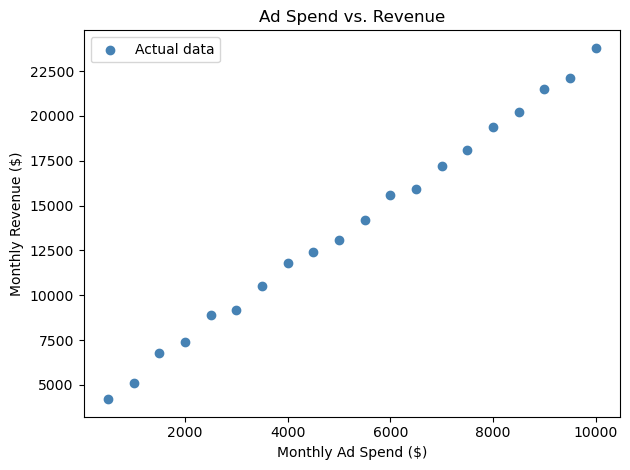

In [30]:
# Scatter plot only
plt.scatter(X2, y2, color='steelblue', label='Actual data')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.tight_layout()
plt.show()

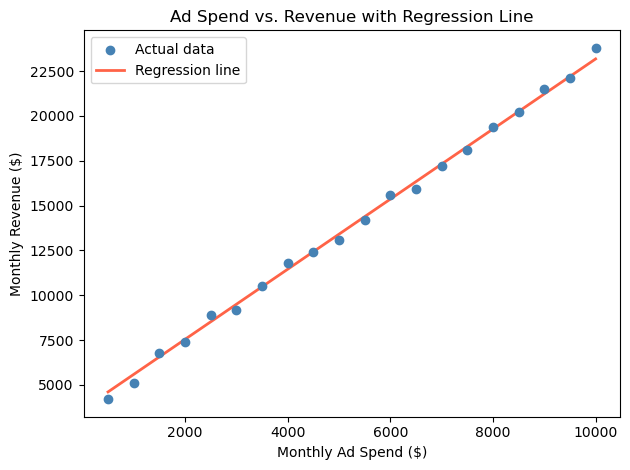

In [31]:
# Scatter plot with regression line overlaid
plt.scatter(X2, y2, color='steelblue', label='Actual data', zorder=3)

x2_range = pd.DataFrame(
    np.linspace(X2['monthly_ad_spend'].min(), X2['monthly_ad_spend'].max(), 100),
    columns=['monthly_ad_spend']
)
y2_line = model2.predict(x2_range)

plt.plot(x2_range, y2_line, color='tomato', linewidth=2, label='Regression line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue with Regression Line')
plt.legend()
plt.tight_layout()
plt.show()

**Visual reflection:** The regression line fits the data very well visually, the data points fall very close to the line with no major outliers and a clear upward linear trend. This matches what the R² score indicated. Both the chart and the metric agree: ad spend is a reliable predictor of revenue for this dataset, and the linear model captures that relationship accurately.

### Experimenting with test_size and random_state

After changing `test_size=0.3` and `random_state=10` and re-running:

- A larger `test_size` (0.3 vs 0.2) means more data goes to testing and less to training, which can slightly reduce the model's accuracy since it has fewer examples to learn from.
- Changing `random_state` changes *which* rows are assigned to train vs test. Different splits can produce slightly different R² scores because the test set contains different data points each time.
- For this particular dataset the relationship is so consistently linear that most splits still produce a very high R², showing the model is robust and not overly sensitive to which specific rows end up in the test set.